<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/AST_Script_TP2_Grupo2_VPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 2 — Análisis de Series Temporales

## Modelos de Machine Learning para el pronóstico de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen

---

## 1. Configuración del entorno

Esta sección detecta el entorno de ejecución (Colab o local), instala las dependencias que falten,
importa las librerías y define las rutas de trabajo.

In [ ]:
# --- Detección de entorno y montaje de Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except Exception:
    EN_COLAB = False
    print('Entorno local detectado: se omite el montaje de Google Drive.')

Mounted at /content/drive


In [ ]:
import sys
import subprocess
import importlib.util

PAQUETES = {
    'great_tables': 'great_tables',
    'pmdarima': 'pmdarima',
    'holidays': 'holidays',
    'arch': 'arch',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
}

faltantes = [pip_name for pip_name, modulo in PAQUETES.items()
             if importlib.util.find_spec(modulo) is None]

if faltantes:
    print(f'Instalando: {", ".join(faltantes)}')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *faltantes], check=False)
else:
    print('Todas las dependencias ya están instaladas.')

Instalando: great_tables, pmdarima, arch


In [ ]:
import hashlib
import itertools
import json
import pathlib
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import holidays
from scipy.stats import boxcox
from great_tables import GT, style, loc, md

from statsmodels.tsa.stattools import adfuller, kpss, acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from arch.unitroot import PhillipsPerron
from pmdarima.arima.seasonality import OCSBTest, CHTest

from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore', category=ConvergenceWarning)

PERIODO_ESTACIONAL = 7
VENTANA_MOVIL = 7

In [ ]:
# --- Rutas de trabajo ---
COLAB_DIR = pathlib.Path('/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')

DATA_DIR = (COLAB_DIR if EN_COLAB else LOCAL_DIR) / 'data'
RAW_DIR = DATA_DIR / 'raw'
CACHE_DIR = DATA_DIR / 'cache'

# Los directorios se crean ANTES de verificar los archivos que viven adentro.
for directorio in (DATA_DIR, RAW_DIR, CACHE_DIR):
    directorio.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {
    'taxi_verde_williamsburg': [
        RAW_DIR / 'green_taxi_williamsburg_trips_24-25.csv',
        RAW_DIR / 'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        RAW_DIR / 'uber_williamsburg_trips_24-25.csv',
        RAW_DIR / 'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        RAW_DIR / 'uber_midtown_center_trips_24-25.csv',
        RAW_DIR / 'uber_midtown_center_trips_25-26.csv',
    ],
}

print(f'Directorio de datos: {DATA_DIR}')
print('Archivos crudos:')
for nombre, rutas in ARCHIVOS.items():
    for ruta in rutas:
        estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
        print(f'  {nombre}: {ruta.name} [{estado}]')

Directorio de datos: /content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final/data
Archivos crudos:
  taxi_verde_williamsburg: green_taxi_williamsburg_trips_24-25.csv [OK]
  taxi_verde_williamsburg: green_taxi_williamsburg_trips_25-26.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_24-25.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_25-26.csv [OK]
  uber_midtown: uber_midtown_center_trips_24-25.csv [OK]
  uber_midtown: uber_midtown_center_trips_25-26.csv [OK]


## 2. Construcción de la serie diaria de ingresos (01/06/2024 – 31/05/2026)

In [ ]:
FECHA_INICIO = '2024-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_INGRESOS = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(rutas_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada.

    Admite una ruta única o una lista de rutas (distintos vintages del mismo
    recorte geográfico), que se concatenan antes de reindexar contra el
    rango de fechas completo.
    """
    if isinstance(rutas_csv, (str, pathlib.Path)):
        rutas_csv = [rutas_csv]

    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    for ruta_csv in rutas_csv:
        lector = pd.read_csv(
            ruta_csv,
            usecols=[columna_fecha, columna_valor],
            parse_dates=[columna_fecha],
            chunksize=chunksize,
        )
        for bloque in lector:
            suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
            acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_INGRESOS.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_INGRESOS, index_col=0, parse_dates=True)
    print(f'Serie leída desde caché: {RUTA_INGRESOS.name}')
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_INGRESOS)
    print(f'Serie construida desde los CSV crudos y guardada en: {RUTA_INGRESOS.name}')

ingresos.index.name = 'fecha'

# `df` es la serie diaria en su escala original, con frecuencia diaria explícita.
df = ingresos.asfreq('D')

assert df.index.min() == pd.Timestamp(FECHA_INICIO) and df.index.max() == pd.Timestamp(FECHA_FIN), \
    'El rango de fechas cargado no coincide con el esperado (2024-06-01 a 2026-05-31).'

print(f'Serie diaria: {df.shape[0]} días, {df.shape[1]} series')
df.head()

Serie leída desde caché: ingresos_diarios.csv
Serie diaria: 730 días, 3 series


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2024-06-01,291.40,339938.85,162255.10
2024-06-02,480.02,254645.27,113694.65
2024-06-03,0.00,106596.77,280473.49
2024-06-04,72.30,105553.50,408520.92
2024-06-05,88.96,124873.13,477617.80


## 3. Configuración de las series

Todo el notebook se apoya en un único diccionario `SERIES`. Ahí se define, para cada serie, su
etiqueta para gráficos y tablas y la transformación de estabilización de varianza que se le aplica.
Los diccionarios auxiliares (`COLUMNAS_ORIGINALES`, `COLUMNAS_MODELO`) se derivan de él, de modo que
**las claves de las series nunca cambian a lo largo del notebook** y las celdas se pueden volver a
ejecutar en cualquier orden.

In [ ]:
SERIES = {
    'taxi_verde_williamsburg': {
        'etiqueta': 'Taxi verde — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_williamsburg': {
        'etiqueta': 'Uber — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_midtown': {
        'etiqueta': 'Uber — Midtown Center',
        'transformacion': 'log1p',
    },
}

TRANSFORMACIONES = {
    'ninguna': (lambda x: x, lambda x: x),
    'log1p': (np.log1p, np.expm1),
    'sqrt': (np.sqrt, np.square),
}

SUFIJOS = {'ninguna': '', 'log1p': '_log1p', 'sqrt': '_sqrt'}


def columna_modelo(serie):
    """Nombre de la columna sobre la que efectivamente se modela la serie."""
    return f'{serie}{SUFIJOS[SERIES[serie]["transformacion"]]}'


def transformar(serie, valores):
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][0](valores)


def destransformar(serie, valores):
    """Devuelve los valores a la escala original (ingresos en dólares)."""
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][1](valores)


# Diccionarios derivados: {columna: etiqueta}
COLUMNAS_ORIGINALES = {serie: cfg['etiqueta'] for serie, cfg in SERIES.items()}
COLUMNAS_MODELO = {
    columna_modelo(serie): (cfg['etiqueta'] if cfg['transformacion'] == 'ninguna'
                            else f'{cfg["etiqueta"]} ({cfg["transformacion"]})')
    for serie, cfg in SERIES.items()
}

for serie, cfg in SERIES.items():
    print(f'{serie:28s} -> columna de modelado: {columna_modelo(serie):36s} '
          f'transformación: {cfg["transformacion"]}')

taxi_verde_williamsburg      -> columna de modelado: taxi_verde_williamsburg              transformación: ninguna
uber_williamsburg            -> columna de modelado: uber_williamsburg                    transformación: ninguna
uber_midtown                 -> columna de modelado: uber_midtown_log1p                   transformación: log1p


#### Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días) de los ingresos diarios, 06/2024–05/2026

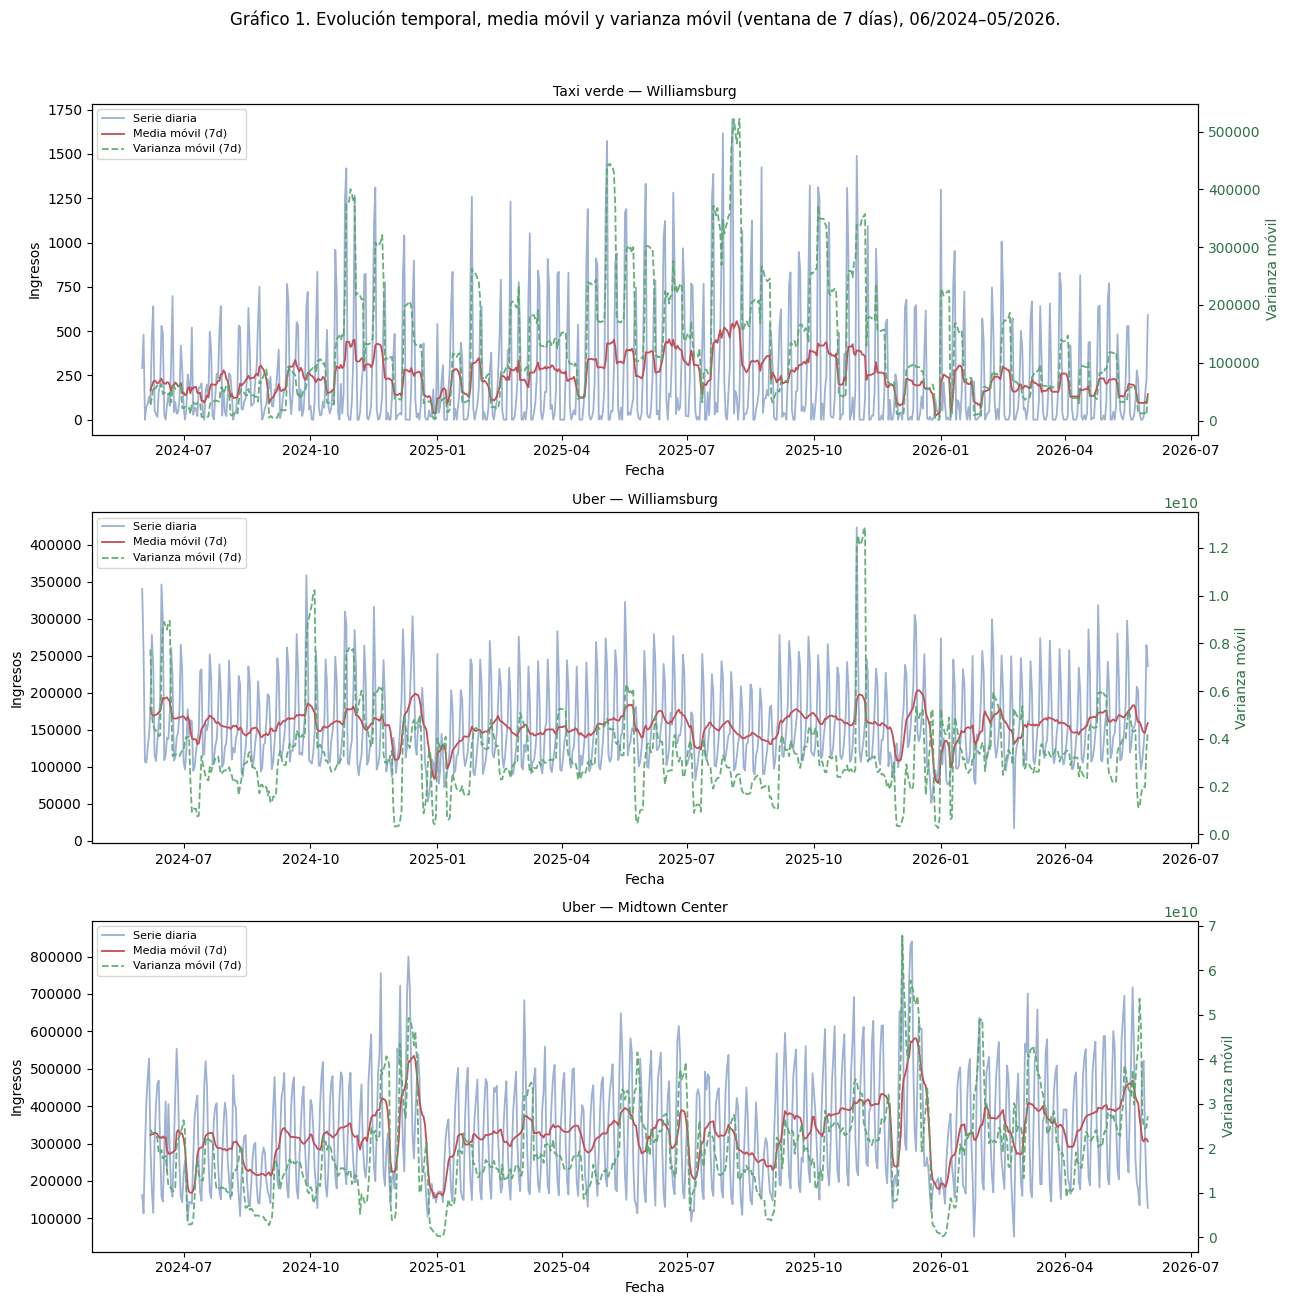

In [ ]:
fig, axes = plt.subplots(nrows=len(COLUMNAS_ORIGINALES), ncols=1, figsize=(13, 13))

for ax1, (col, titulo) in zip(axes, COLUMNAS_ORIGINALES.items()):
    serie = df[col]
    media_movil = serie.rolling(VENTANA_MOVIL).mean()
    var_movil = serie.rolling(VENTANA_MOVIL).var()

    ax1.plot(serie.index, serie.values, lw=1.3, alpha=0.55, color='#4C72B0', label='Serie diaria')
    ax1.plot(serie.index, media_movil, lw=1.3, color='#C44E52', label=f'Media móvil ({VENTANA_MOVIL}d)')
    ax1.set_ylabel('Ingresos')
    ax1.set_xlabel('Fecha')

    ax2 = ax1.twinx()
    ax2.plot(serie.index, var_movil, lw=1.3, color='#55A868', alpha=0.9,
             linestyle='--', label=f'Varianza móvil ({VENTANA_MOVIL}d)')
    ax2.set_ylabel('Varianza móvil', color='#2E7047')
    ax2.tick_params(axis='y', labelcolor='#2E7047')

    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', fontsize=8)

    ax1.set_title(titulo, fontsize=10)

fig.suptitle('Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días), 06/2024–05/2026.',
             fontsize=12, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 4. Estabilización de la varianza

Se combinan dos diagnósticos sobre las series en su escala original: el método Rango-Mediana
(regresión de ln(Rango) sobre ln(Mediana), donde λ ≈ 1 − pendiente) y la estimación de λ por máxima
verosimilitud de Box-Cox con su intervalo de confianza al 95%.

In [ ]:
def analyze_rango_mediana(series, window_size=VENTANA_MOVIL):
    """Divide la serie en subgrupos, calcula rango y mediana,
    y ajusta: ln(Rango) = a + b * ln(Mediana).

    Descarta los subgrupos con mediana o rango <= 0, que no admiten logaritmo.
    """
    n = len(series)
    num_groups = n // window_size
    medianas, rangos = [], []

    for i in range(num_groups):
        subgroup = series[i * window_size:(i + 1) * window_size]
        medianas.append(np.median(subgroup))
        rangos.append(np.max(subgroup) - np.min(subgroup))

    medianas, rangos = np.array(medianas), np.array(rangos)

    mask = (medianas > 0) & (rangos > 0)
    n_descartados = int((~mask).sum())
    if n_descartados > 0:
        print(f'  [aviso] se descartaron {n_descartados} de {len(medianas)} subgrupos por mediana o rango <= 0')
    medianas, rangos = medianas[mask], rangos[mask]

    log_medianas, log_rangos = np.log(medianas), np.log(rangos)
    slope, intercept = np.polyfit(log_medianas, log_rangos, 1)

    y_pred = slope * log_medianas + intercept
    r_squared = 1 - (np.sum((log_rangos - y_pred) ** 2) / np.sum((log_rangos - np.mean(log_rangos)) ** 2))

    return {
        'medianas': medianas, 'rangos': rangos, 'intercept': intercept,
        'slope': slope, 'r_squared': r_squared, 'lambda_empirico': 1 - slope,
    }


def calcular_shift(series, margen=1.0):
    """Corrimiento fijo y explícito para series con valores <= 0 (Box-Cox lo requiere)."""
    minimo = np.min(series)
    return (-minimo + margen) if minimo <= 0 else 0.0


def get_boxcox_ci(series, alpha=0.05):
    """Lambda óptimo por MLE y su IC al (1-alpha) usando scipy.stats.boxcox.

    Aplica el corrimiento automáticamente si la serie tiene valores <= 0. Ese
    corrimiento afecta el λ estimado, así que el resultado es orientativo para
    las series con ceros (taxi verde).
    """
    shift = calcular_shift(series)
    series_shifted = np.asarray(series, dtype=float) + shift

    _, l_opt, ci = boxcox(series_shifted, alpha=alpha)
    ci_lower, ci_upper = ci

    return l_opt, ci_lower, ci_upper, shift


filas = []
for col, titulo in COLUMNAS_ORIGINALES.items():
    serie_valores = df[col].dropna().values

    rm = analyze_rango_mediana(serie_valores)
    l_opt, ci_inf, ci_sup, shift = get_boxcox_ci(serie_valores)

    filas.append({
        'Serie': titulo,
        'Pendiente (b)': rm['slope'],
        'R² (Ajuste empírico)': rm['r_squared'],
        'Lambda Empírico (1-b)': rm['lambda_empirico'],
        'Lambda Óptimo (MLE)': l_opt,
        'IC 95% Inferior': ci_inf,
        'IC 95% Superior': ci_sup,
    })

tabla_varianza = pd.DataFrame(filas)

(
    GT(tabla_varianza)
    .tab_header(
        title=f'Tabla 1. Estabilización de varianza: Rango-Mediana (ventana={VENTANA_MOVIL}) vs. Box-Cox MLE'
    )
    .fmt_number(
        columns=['Pendiente (b)', 'R² (Ajuste empírico)', 'Lambda Empírico (1-b)',
                 'Lambda Óptimo (MLE)', 'IC 95% Inferior', 'IC 95% Superior'],
        decimals=3
    )
    .cols_label(**{
        'Pendiente (b)': md('Pendiente<br>(b)'),
        'R² (Ajuste empírico)': md('R²<br>(ajuste empírico)'),
        'Lambda Empírico (1-b)': md('λ empírico<br>(1-b)'),
        'Lambda Óptimo (MLE)': md('λ óptimo<br>(MLE)'),
        'IC 95% Inferior': md('IC 95%<br>inferior'),
        'IC 95% Superior': md('IC 95%<br>superior'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

  [aviso] se descartaron 4 de 104 subgrupos por mediana o rango <= 0


GT(_tbl_data=                       Serie  Pendiente (b)  R² (Ajuste empírico)  \
0  Taxi verde — Williamsburg       0.091088              0.020613   
1        Uber — Williamsburg       0.356069              0.031158   
2      Uber — Midtown Center       1.399196              0.587331   

   Lambda Empírico (1-b)  Lambda Óptimo (MLE)  IC 95% Inferior  \
0               0.908912             0.159155         0.124715   
1               0.643931            -0.018086        -0.152673   
2              -0.399196             0.233993         0.084535   

   IC 95% Superior  
0         0.193847  
1         0.124927  
2         0.385616  , _body=<great_tables._gt_data.Body object at 0x7b0a274e6900>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Pendiente (b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Pendiente<br>(b)'), column_align='right', column_width=None), ColInfo(var='R² (Ajuste empírico)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='R²<br>(ajuste empírico)'), column_align='right', column_width=None), ColInfo(var='Lambda Empírico (1-b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ empírico<br>(1-b)'), column_align='right', column_width=None), ColInfo(var='Lambda Óptimo (MLE)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ óptimo<br>(MLE)'), column_align='right', column_width=None), ColInfo(var='IC 95% Inferior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>inferior'), column_align='right', column_width=None), ColInfo(var='IC 95% Superior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>superior'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b0a274e6660>, _spanners=Spanners([]), _heading=Heading(title='Tabla 1. Estabilización de varianza: Rango-Mediana (ventana=7) vs. Box-Cox MLE', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b0a274e6cf0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b0a24859d10>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b0a274e6e40>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b0a274e6ba0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInf

### Transformación aplicada

In [ ]:
df_modelo = df.copy()

for serie, cfg in SERIES.items():
    if cfg['transformacion'] == 'ninguna':
        continue
    assert (df[serie].dropna() >= 0).all(), \
        f'Hay valores negativos en {serie}: no se puede aplicar {cfg["transformacion"]}'
    df_modelo[columna_modelo(serie)] = transformar(serie, df[serie])

# Verificación de que la inversa reconstruye la serie original
for serie in SERIES:
    reconstruida = destransformar(serie, df_modelo[columna_modelo(serie)])
    assert np.allclose(reconstruida.dropna(), df[serie].dropna()), \
        f'La transformación inversa de {serie} no reconstruye la serie original'

print('Columnas de modelado:', list(COLUMNAS_MODELO))
df_modelo[[columna_modelo(s) for s in SERIES]].head()

Columnas de modelado: ['taxi_verde_williamsburg', 'uber_williamsburg', 'uber_midtown_log1p']


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown_log1p
fecha,,,
2024-06-01,291.40,339938.85,11.996931
2024-06-02,480.02,254645.27,11.641280
2024-06-03,0.00,106596.77,12.544238
2024-06-04,72.30,105553.50,12.920301
2024-06-05,88.96,124873.13,13.076568


## 5. Diagnóstico de estacionariedad

#### Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)

In [ ]:
filas = []
for col, titulo in COLUMNAS_MODELO.items():
    valores = df_modelo[col].dropna().values

    D_ocsb = OCSBTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)
    D_ch = CHTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)

    filas.append({'Serie': titulo, 'D (OCSB)': D_ocsb, 'D (Canova-Hansen)': D_ch})

tabla_estacional = pd.DataFrame(filas)

(
    GT(tabla_estacional)
    .tab_header(
        title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)',
        subtitle=f'Orden de diferenciación estacional recomendado (m={PERIODO_ESTACIONAL})'
    )
    .cols_label(**{
        'D (OCSB)': md('D<br>(OCSB)'),
        'D (Canova-Hansen)': md('D<br>(Canova-Hansen)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

GT(_tbl_data=                           Serie  D (OCSB)  D (Canova-Hansen)
0      Taxi verde — Williamsburg         0                  0
1            Uber — Williamsburg         0                  0
2  Uber — Midtown Center (log1p)         0                  0, _body=<great_tables._gt_data.Body object at 0x7b0a248e0b00>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='D (OCSB)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(OCSB)'), column_align='right', column_width=None), ColInfo(var='D (Canova-Hansen)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(Canova-Hansen)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b0a2485a0d0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)', subtitle='Orden de diferenciación estacional recomendado (m=7)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b0a2485ae90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b0a248e0d60>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b0a2485aad0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A

#### Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)

Las tres pruebas se aplican sobre las series **en nivel** (sin diferenciar), con especificación `'c'`
(constante, sin tendencia). El objetivo es confirmar el orden de diferenciación regular *d*.

In [ ]:
def pruebas_raiz_unitaria(serie, nombre, especificacion='c'):
    """Aplica las pruebas ADF, Phillips-Perron y KPSS a una serie.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """
    serie = serie.dropna()

    # statsmodels >= 0.15 avisa que va a cambiar el tipo de retorno de adfuller y kpss.
    # Se silencia solo ese aviso; las advertencias de interpolación del KPSS se conservan
    # porque informan que el p-valor está fuera de la tabla.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        adf = adfuller(serie, regression=especificacion, autolag='AIC')
        pp = PhillipsPerron(serie, trend=especificacion)
        kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')

    return pd.DataFrame({
        'Serie': [nombre] * 3,
        'Prueba': ['ADF', 'Phillips-Perron', 'KPSS'],
        'Estadístico': [adf[0], pp.stat, kpss_resultado[0]],
        'p-valor': [adf[1], pp.pvalue, kpss_resultado[1]],
        'Rezagos': [adf[2], pp.lags, kpss_resultado[2]],
    })


tabla_raiz_unitaria = pd.concat(
    [pruebas_raiz_unitaria(df_modelo[col], titulo, especificacion='c')
     for col, titulo in COLUMNAS_MODELO.items()],
    ignore_index=True
)

(
    GT(tabla_raiz_unitaria)
    .tab_header(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)')
    .fmt_number(columns=['Estadístico', 'p-valor'], decimals=4)
    .tab_options(table_font_names='Arial')
)

/tmp/ipykernel_1595/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')
/tmp/ipykernel_1595/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')


GT(_tbl_data=                           Serie           Prueba  Estadístico       p-valor  \
0      Taxi verde — Williamsburg              ADF    -3.140587  2.369174e-02   
1      Taxi verde — Williamsburg  Phillips-Perron   -17.181302  6.644116e-30   
2      Taxi verde — Williamsburg             KPSS     0.145879  1.000000e-01   
3            Uber — Williamsburg              ADF    -4.712843  7.960016e-05   
4            Uber — Williamsburg  Phillips-Perron   -14.845177  1.811889e-27   
5            Uber — Williamsburg             KPSS     0.321584  1.000000e-01   
6  Uber — Midtown Center (log1p)              ADF    -4.557168  1.548024e-04   
7  Uber — Midtown Center (log1p)  Phillips-Perron   -10.875379  1.335824e-19   
8  Uber — Midtown Center (log1p)             KPSS     0.587412  2.378076e-02   

   Rezagos  
0       20  
1       20  
2      129  
3       20  
4       20  
5      574  
6       20  
7       20  
8       36  , _body=<great_tables._gt_data.Body object at 0x7b0a274f6580>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Prueba', type=<ColInfoTypeEnum.default: 1>, column_label='Prueba', column_align='left', column_width=None), ColInfo(var='Estadístico', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b0a2485b110>, _spanners=Spanners([]), _heading=Heading(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b0a248e1350>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b0a249204d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b0a2485b750>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b0a2485bb10>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), tab

#### Gráfico 2. FAS, FAC y FACP de las series de modelado

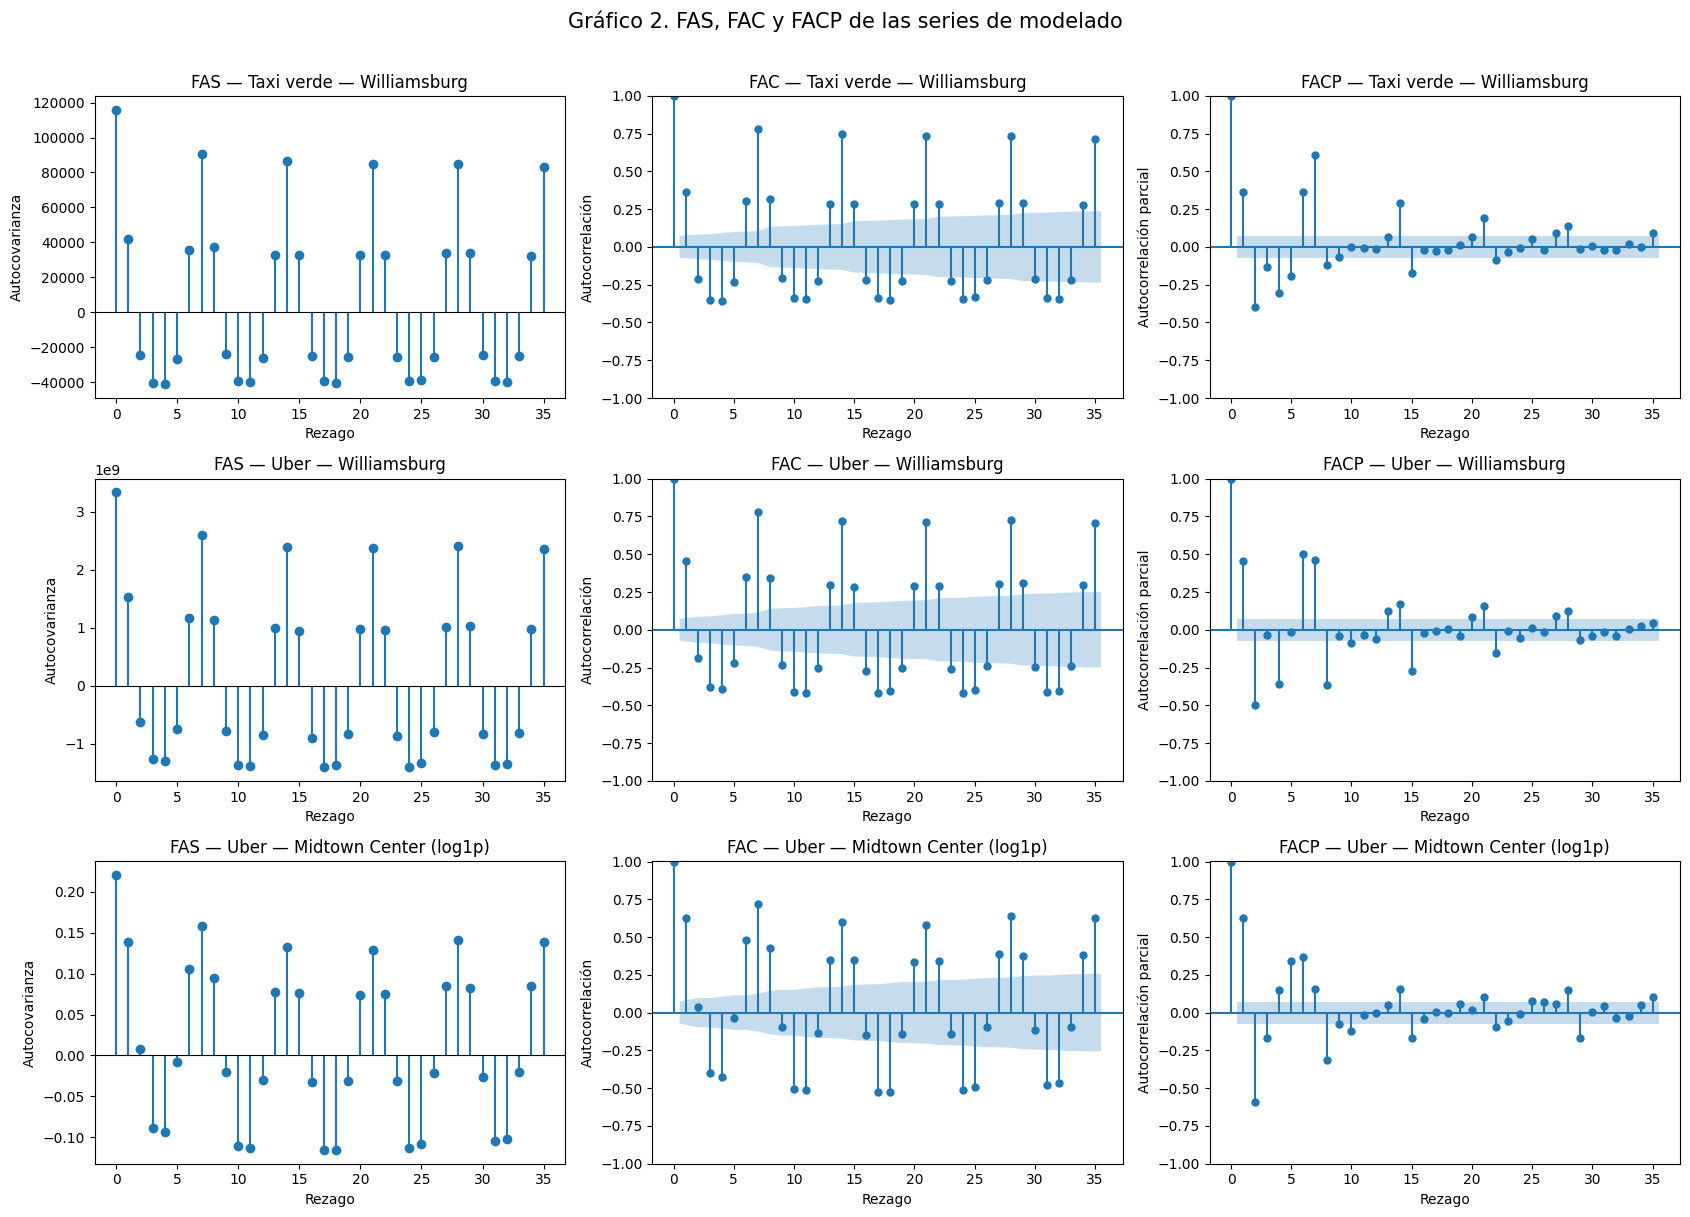

In [ ]:
MAX_LAGS = 35


def graficar_dependencia_temporal(datos, columnas, titulo_general, max_lags=MAX_LAGS):
    """Grafica FAS, FAC y FACP (una fila por serie) para las columnas indicadas."""
    fig, axes = plt.subplots(nrows=len(columnas), ncols=3, figsize=(17, 4 * len(columnas)))

    for fila, (columna, titulo) in enumerate(columnas.items()):
        serie = datos[columna].dropna()

        # FAS (función de autocovarianza muestral)
        autocovarianzas = acovf(serie, adjusted=False, demean=True, fft=True, nlag=max_lags)
        axes[fila, 0].stem(range(len(autocovarianzas)), autocovarianzas, basefmt=' ')
        axes[fila, 0].axhline(0, color='black', linewidth=0.8)
        axes[fila, 0].set_title(f'FAS — {titulo}')
        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(serie, lags=max_lags, alpha=0.05, zero=True, ax=axes[fila, 1])
        axes[fila, 1].set_title(f'FAC — {titulo}')
        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(serie, lags=max_lags, alpha=0.05, zero=True, method='ywm', ax=axes[fila, 2])
        axes[fila, 2].set_title(f'FACP — {titulo}')
        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(titulo_general, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


graficar_dependencia_temporal(
    datos=df_modelo,
    columnas=COLUMNAS_MODELO,
    titulo_general='Gráfico 2. FAS, FAC y FACP de las series de modelado',
)

## 6. Variables exógenas de calendario

Se construyen dos conjuntos de variables a partir del índice de fechas:

- **`exog_calendario`**: variables de calendario completas (día del mes, día de la semana, semana del
  año, mes, trimestre, año, feriado). Se usan como *features* para los modelos de Machine Learning,
  que pueden manejar relaciones no lineales entre esas variables y el target.
- **Bloques exógenos para SARIMAX**: solo el indicador de feriados y las dummies de año. El resto de
  las variables de calendario no se pasan a SARIMAX porque como enteros impondrían una relación
  lineal sin sentido (diciembre no es "doce veces" enero) y porque mes / trimestre / semana se
  solapan con la estacionalidad semanal que ya capturan los términos (P, D, Q, s=7).

Las dummies de año se construyen con `drop_first=True` para evitar colinealidad perfecta con la
constante del modelo: el año 2024 queda como categoría base.

In [ ]:
ANIOS = range(df_modelo.index.year.min(), df_modelo.index.year.max() + 1)
feriados_us_ny = holidays.country_holidays('US', subdiv='NY', years=list(ANIOS))

exog_calendario = pd.DataFrame(index=df_modelo.index)
exog_calendario['dayofmonth'] = df_modelo.index.day
exog_calendario['dayofweek'] = df_modelo.index.dayofweek
exog_calendario['weekofyear'] = df_modelo.index.isocalendar().week.astype(int).values
exog_calendario['month'] = df_modelo.index.month
exog_calendario['quarter'] = df_modelo.index.quarter
exog_calendario['year'] = df_modelo.index.year
exog_calendario['holiday'] = [int(fecha in feriados_us_ny) for fecha in df_modelo.index.date]

# Dummies de año (2024 = categoría base)
dummies_anio = pd.get_dummies(df_modelo.index.year.astype(str), prefix='anio', drop_first=True).astype(int)
dummies_anio.index = df_modelo.index
COLS_ANIO = list(dummies_anio.columns)

# Tabla de exógenas disponible para SARIMAX
exog_sarimax = pd.concat([exog_calendario[['holiday']], dummies_anio], axis=1)

# Variantes que se comparan en el grid search
EXOG_VARIANTES = {
    'sin_exogenas': [],
    'feriados': ['holiday'],
    'anio': COLS_ANIO,
    'feriados_anio': ['holiday'] + COLS_ANIO,
}

print(f'Feriados US/NY en el período ({FECHA_INICIO} a {FECHA_FIN}): {exog_calendario["holiday"].sum()} días')
print(f'Dummies de año: {COLS_ANIO} (base: {min(ANIOS)})')
print(f'Variantes exógenas a comparar: {list(EXOG_VARIANTES)}')
exog_sarimax.head()

Feriados US/NY en el período (2024-06-01 a 2026-05-31): 28 días
Dummies de año: ['anio_2025', 'anio_2026'] (base: 2024)
Variantes exógenas a comparar: ['sin_exogenas', 'feriados', 'anio', 'feriados_anio']


,holiday,anio_2025,anio_2026
fecha,,,
2024-06-01,0,0,0
2024-06-02,0,0,0
2024-06-03,0,0,0
2024-06-04,0,0,0
2024-06-05,0,0,0


## 7. Variables autorregresivas (rezagos y estadísticos móviles)

Este bloque prepara la matriz de *features* para los modelos de Machine Learning. Los estadísticos
móviles se calculan sobre la serie desplazada un día, de modo que en *t* solo resuman información
hasta *t−1* (sin *leakage*).

In [ ]:
LAGS = [1, 2, 7, 14, 21, 28, 30, 35]
VENTANAS_ROLLING = [7, 14, 28, 35]


def agregar_features_autorregresivas(serie, lags=LAGS, ventanas=VENTANAS_ROLLING):
    """Construye rezagos y estadísticos móviles (media, desvío) de `serie`."""
    feats = pd.DataFrame(index=serie.index)

    for lag in lags:
        feats[f'lag_{lag}'] = serie.shift(lag)

    serie_desplazada = serie.shift(1)
    for ventana in ventanas:
        rolling = serie_desplazada.rolling(ventana)
        feats[f'rolling_mean_{ventana}'] = rolling.mean()
        feats[f'rolling_std_{ventana}'] = rolling.std()

    return feats


features_por_serie = {}

for serie in SERIES:
    col = columna_modelo(serie)
    feats_autorregresivas = agregar_features_autorregresivas(df_modelo[col])
    features_completas = exog_calendario.join(feats_autorregresivas)
    features_completas['target'] = df_modelo[col]
    features_por_serie[serie] = features_completas

    n_features = features_completas.shape[1] - 1
    n_nan = features_completas.drop(columns='target').isna().any(axis=1).sum()
    print(f'{serie:28s}: {features_completas.shape[0]} filas, {n_features} features '
          f'(+ target) | filas con algún NaN: {n_nan}')

features_por_serie['uber_midtown'].dropna().head()

taxi_verde_williamsburg     : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_williamsburg           : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_midtown                : 730 filas, 23 features (+ target) | filas con algún NaN: 35


,dayofmonth,dayofweek,weekofyear,month,quarter,year,holiday,lag_1,lag_2,lag_7,...,lag_35,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_mean_35,rolling_std_35,target
fecha,,,,,,,,,,,,,,,,,,,,,
2024-07-06,6,5,27,7,3,2024,0,11.880252,11.447113,11.963767,...,11.996931,12.004201,0.326048,12.308611,0.507195,12.406047,0.485056,12.437309,0.497784,11.871217
2024-07-07,7,6,27,7,3,2024,0,11.871217,11.880252,11.872747,...,11.641280,11.990979,0.329815,12.293747,0.517379,12.398744,0.491707,12.433717,0.501495,11.838551
2024-07-08,8,0,28,7,3,2024,0,11.838551,11.871217,12.290677,...,12.544238,11.986094,0.332104,12.284399,0.524818,12.405530,0.482190,12.439353,0.493369,12.475636
2024-07-09,9,1,28,7,3,2024,0,12.475636,11.838551,12.446668,...,12.920301,12.012517,0.366003,12.274829,0.519628,12.400040,0.480419,12.437393,0.493076,12.819589
2024-07-10,10,2,28,7,3,2024,0,12.819589,12.475636,12.128184,...,13.076568,12.065791,0.455844,12.263699,0.504929,12.396863,0.477216,12.434516,0.490462,12.912920


## 8. Benchmark estadístico: SARIMAX

### 8.1. Partición train / test

La partición usa meses calendario completos: el test es el último mes de la serie (mayo de 2026) y el
train es todo lo anterior. La selección de hiperparámetros se hace **exclusivamente sobre train**
(por AIC / BIC); el test no interviene en ningún momento de esta etapa.

In [ ]:
def dividir_train_test(serie):
    """Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie (mayo de 2026)
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test


splits = {}
for serie in SERIES:
    train, test = dividir_train_test(df_modelo[columna_modelo(serie)])
    splits[serie] = (train, test)
    print(f'{serie:28s}: train {train.index.min().date()} a {train.index.max().date()} '
          f'({len(train)} días) | test {test.index.min().date()} a {test.index.max().date()} '
          f'({len(test)} días)')

taxi_verde_williamsburg     : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_williamsburg           : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_midtown                : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)


### 8.2. Espacio de búsqueda

Los rangos por serie salen del análisis del TP1 (FAC / FACP y resultados del grid search previo).
Se comparan dos familias:

- **SARIMAX**: usa los rangos estacionales (P, D, Q) de cada serie.
- **ARIMAX**: caso particular sin componente estacional (P = D = Q = 0).

Una aclaración importante sobre la comparabilidad del AIC: el criterio solo se puede comparar entre
modelos ajustados sobre **la misma variable dependiente y la misma muestra**. Por eso *d* y *D* se
fijan en 0 en todas las familias, incluida ARIMAX (en la versión anterior del script ARIMAX tenía
`d=(0, 1)`, lo que habría mezclado en un mismo ranking modelos sobre la serie en nivel y sobre la
serie diferenciada). Con d = D = 0, en cambio, el AIC **sí** es comparable entre variantes con y sin
exógenas, que es justamente lo que permite responder si conviene incorporarlas.

In [ ]:
configuracion_series = {
    'taxi_verde_williamsburg': dict(p=(0, 3), d=(0, 0), q=(0, 1), P=(0, 1), D=(0, 0), Q=(0, 2)),
    'uber_williamsburg':       dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(1, 2), D=(0, 0), Q=(0, 2)),
    'uber_midtown':            dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(1, 2), D=(0, 0), Q=(0, 2)),
}

# SARIMAX toma los rangos estacionales de configuracion_series.
# ARIMAX los anula (P = D = Q = 0) y amplía p y q.
FAMILIAS = {
    'SARIMAX': None,
    'ARIMAX': dict(p=(0, 3), d=(0, 0), q=(0, 3), P=(0, 0), D=(0, 0), Q=(0, 0)),
}


def rangos_de(serie, familia):
    """Devuelve los rangos (p, d, q, P, D, Q) para una serie y una familia."""
    base = dict(configuracion_series[serie])
    override = FAMILIAS[familia]
    if override is not None:
        base.update(override)
    return base


for serie in SERIES:
    for familia in FAMILIAS:
        r = rangos_de(serie, familia)
        n_comb = int(np.prod([r[k][1] - r[k][0] + 1 for k in ('p', 'd', 'q', 'P', 'D', 'Q')]))
        print(f'{serie:28s} {familia:8s}: {n_comb:4d} combinaciones x {len(EXOG_VARIANTES)} variantes '
              f'exógenas = {n_comb * len(EXOG_VARIANTES):5d} ajustes')

taxi_verde_williamsburg      SARIMAX :   48 combinaciones x 4 variantes exógenas =   192 ajustes
taxi_verde_williamsburg      ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_williamsburg            SARIMAX :   72 combinaciones x 4 variantes exógenas =   288 ajustes
uber_williamsburg            ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_midtown                 SARIMAX :   72 combinaciones x 4 variantes exógenas =   288 ajustes
uber_midtown                 ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes


### 8.3. Grid search con caché

La búsqueda es exhaustiva sobre el producto cartesiano de los rangos. Para no tener que rehacer el
trabajo, los resultados se cachean en disco (Google Drive) con estas características:

- **Un archivo por combinación de (serie, familia, variante exógena)**, con un hash en el nombre que
  resume los rangos, el período estacional, las columnas exógenas y las fechas del train. Si cambiás
  cualquiera de esas cosas, el hash cambia y esa búsqueda se recalcula; el resto queda intacto.
- **Guardado incremental**: el caché se persiste cada `guardar_cada` modelos ajustados, no al final.
  Si se corta Colab a mitad de camino, al volver a ejecutar la celda se retoma exactamente donde
  quedó, ajustando solo las combinaciones pendientes.
- **Las combinaciones que fallan también se cachean**, con su estado de error, para no reintentarlas
  en cada corrida.
- `FORZAR_RECALCULO_GRID = True` ignora el caché y vuelve a ajustar todo desde cero.

In [ ]:
CACHE_GRID_DIR = CACHE_DIR / 'gridsearch'
CACHE_GRID_DIR.mkdir(parents=True, exist_ok=True)

FORZAR_RECALCULO_GRID = False
VERSION_GRID = 'v1'  # cambiar si se modifica la lógica de ajuste (invalida todo el caché)


def _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog):
    """Diccionario que identifica unívocamente una búsqueda."""
    return {
        'version': VERSION_GRID,
        'serie': serie,
        'familia': familia,
        'variante': variante,
        'rangos': {k: list(v) for k, v in sorted(rangos.items())},
        's': s,
        'cols_exog': sorted(cols_exog),
        'n_train': int(len(y_train)),
        'train_inicio': str(y_train.index.min().date()),
        'train_fin': str(y_train.index.max().date()),
        'transformacion': SERIES[serie]['transformacion'],
    }


def _ruta_cache(firma):
    texto = json.dumps(firma, sort_keys=True, ensure_ascii=False)
    hash_corto = hashlib.md5(texto.encode('utf-8')).hexdigest()[:10]
    nombre = f'{firma["serie"]}__{firma["familia"]}__{firma["variante"]}__{hash_corto}.pkl'
    return CACHE_GRID_DIR / nombre


def _guardar_cache(ruta, contenido):
    """Escritura en archivo temporal + reemplazo, para no dejar un pickle a medio escribir
    si el entorno se corta justo durante el guardado."""
    ruta_tmp = ruta.with_suffix('.tmp')
    with open(ruta_tmp, 'wb') as f:
        pickle.dump(contenido, f)
    ruta_tmp.replace(ruta)


def grid_search_sarimax(serie, familia, variante, y_train, exog_train=None,
                        s=PERIODO_ESTACIONAL, criterio='AIC',
                        forzar=FORZAR_RECALCULO_GRID, guardar_cada=10, verbose=True):
    """Búsqueda exhaustiva de hiperparámetros SARIMAX por grid search, con caché en disco.

    Ajusta un modelo por cada combinación (p,d,q)(P,D,Q,s) de los rangos definidos para
    esa serie y familia, y lo evalúa por AIC / BIC sobre train. El test no interviene.

    Devuelve un DataFrame con los modelos que ajustaron correctamente, ordenado por `criterio`.
    """
    rangos = rangos_de(serie, familia)
    cols_exog = list(exog_train.columns) if exog_train is not None else []

    firma = _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog)
    ruta = _ruta_cache(firma)

    # --- Lectura del caché ---
    evaluados = {}
    if ruta.exists() and not forzar:
        with open(ruta, 'rb') as f:
            cache = pickle.load(f)
        if cache.get('firma') == firma:
            evaluados = cache['resultados']

    combinaciones = list(itertools.product(*[
        range(rangos[k][0], rangos[k][1] + 1) for k in ('p', 'd', 'q', 'P', 'D', 'Q')
    ]))
    pendientes = [c for c in combinaciones if c not in evaluados]

    if verbose:
        print(f'  {serie} | {familia} | {variante}: {len(combinaciones)} combinaciones '
              f'({len(evaluados)} en caché, {len(pendientes)} pendientes)')

    # --- Ajuste de las combinaciones pendientes ---
    for i, combo in enumerate(pendientes, start=1):
        pp, dd, qq, PP, DD, QQ = combo
        order = (pp, dd, qq)
        seasonal_order = (PP, DD, QQ, s)

        try:
            modelo = SARIMAX(
                y_train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            )
            ajuste = modelo.fit(disp=False)
            evaluados[combo] = {
                'estado': 'ok',
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': float(ajuste.aic),
                'BIC': float(ajuste.bic),
                'LLF': float(ajuste.llf),
                'convergio': bool(ajuste.mle_retvals.get('converged', True)),
                'n_params': int(len(ajuste.params)),
            }
        except Exception as error:
            evaluados[combo] = {
                'estado': 'error',
                'order': order,
                'seasonal_order': seasonal_order,
                'mensaje': f'{type(error).__name__}: {error}',
            }

        if i % guardar_cada == 0 or i == len(pendientes):
            _guardar_cache(ruta, {'firma': firma, 'resultados': evaluados})
            if verbose:
                print(f'    {i}/{len(pendientes)} ajustadas (caché guardado)')

    # --- Armado del DataFrame de salida ---
    validos = [r for r in evaluados.values() if r['estado'] == 'ok']
    n_errores = len(evaluados) - len(validos)

    if verbose:
        print(f'    Completado: {len(validos)} modelos válidos, {n_errores} con error.')

    if not validos:
        return pd.DataFrame(columns=['order', 'seasonal_order', 'AIC', 'BIC', 'LLF',
                                     'convergio', 'n_params'])

    return (
        pd.DataFrame(validos)
        .drop(columns='estado')
        .sort_values(by=criterio)
        .reset_index(drop=True)
    )

### 8.4. Ejecución de la búsqueda

Se recorren las tres series, las dos familias y las cuatro variantes exógenas
(`sin_exogenas`, `feriados`, `anio`, `feriados_anio`). La primera corrida completa es larga; las
siguientes se resuelven casi por completo desde el caché.

In [ ]:
resultados_grid = {}   # (serie, familia, variante) -> DataFrame completo, ordenado por AIC
mejores = []           # una fila por combinación, con el mejor modelo de cada búsqueda

for serie in SERIES:
    y_train, _ = splits[serie]

    for familia in FAMILIAS:
        for variante, cols in EXOG_VARIANTES.items():
            exog_train = (exog_sarimax.loc[y_train.index, cols].astype(float)
                          if cols else None)

            res = grid_search_sarimax(
                serie=serie, familia=familia, variante=variante,
                y_train=y_train, exog_train=exog_train,
            )
            resultados_grid[(serie, familia, variante)] = res

            if not res.empty:
                mejor = res.iloc[0]
                mejores.append({
                    'serie': serie,
                    'Serie': SERIES[serie]['etiqueta'],
                    'Familia': familia,
                    'Variante exógena': variante,
                    'k exógenas': len(cols),
                    'order': str(mejor['order']),
                    'seasonal_order': str(mejor['seasonal_order']),
                    'AIC': mejor['AIC'],
                    'BIC': mejor['BIC'],
                    # se conservan las tuplas para poder reconstruir el modelo más adelante
                    'order_t': mejor['order'],
                    'seasonal_order_t': mejor['seasonal_order'],
                })

tabla_mejores = pd.DataFrame(mejores)
print(f'\nBúsquedas completadas: {len(resultados_grid)}')
tabla_mejores.drop(columns=['serie', 'order_t', 'seasonal_order_t'])

### 8.5. ¿Conviene incorporar las variables exógenas?

La comparación se hace dentro de cada par (serie, familia): se toma el mejor modelo sin exógenas
como referencia y se calcula el ΔAIC de cada variante contra él. Un ΔAIC **negativo** indica que
la variante con exógenas mejora el ajuste.

Como criterio de lectura habitual, una diferencia de menos de 2 puntos de AIC se considera evidencia
débil (los modelos son prácticamente equivalentes y conviene quedarse con el más parsimonioso, o sea
el que no incorpora exógenas); entre 2 y 10 puntos, evidencia moderada; más de 10 puntos, evidencia
fuerte a favor del modelo con menor AIC.

In [ ]:
tabla_comparacion = tabla_mejores.copy()

# Referencia: el mejor modelo sin exógenas de cada par (serie, familia)
referencia = (
    tabla_comparacion[tabla_comparacion['Variante exógena'] == 'sin_exogenas']
    .set_index(['serie', 'Familia'])[['AIC', 'BIC']]
    .rename(columns={'AIC': 'AIC_ref', 'BIC': 'BIC_ref'})
)

tabla_comparacion = tabla_comparacion.join(referencia, on=['serie', 'Familia'])
tabla_comparacion['Δ AIC'] = tabla_comparacion['AIC'] - tabla_comparacion['AIC_ref']
tabla_comparacion['Δ BIC'] = tabla_comparacion['BIC'] - tabla_comparacion['BIC_ref']


def leer_delta(delta):
    """Lectura del ΔAIC respecto del mejor modelo sin exógenas."""
    if delta <= -10:
        return 'Mejora fuerte'
    if delta <= -2:
        return 'Mejora moderada'
    if delta < 2:
        return 'Equivalente (elegir el más parsimonioso)'
    if delta < 10:
        return 'Empeora levemente'
    return 'Empeora'


tabla_comparacion['Evidencia'] = tabla_comparacion['Δ AIC'].apply(leer_delta)
tabla_comparacion.loc[tabla_comparacion['Variante exógena'] == 'sin_exogenas', 'Evidencia'] = '— (referencia)'

tabla_comparacion = (
    tabla_comparacion
    .sort_values(['Serie', 'Familia', 'AIC'])
    .drop(columns=['serie', 'AIC_ref', 'BIC_ref', 'order_t', 'seasonal_order_t'])
    .reset_index(drop=True)
)

(
    GT(tabla_comparacion, groupname_col='Serie')
    .tab_header(
        title='Tabla 4. Grid search SARIMAX / ARIMAX: comparación de variantes exógenas',
        subtitle='Mejor modelo por variante (AIC sobre train). Δ calculado contra el mejor modelo sin exógenas de cada familia.'
    )
    .fmt_number(columns=['AIC', 'BIC', 'Δ AIC', 'Δ BIC'], decimals=2)
    .cols_label(**{
        'Variante exógena': md('Variante<br>exógena'),
        'k exógenas': md('k<br>exógenas'),
        'order': md('(p,d,q)'),
        'seasonal_order': md('(P,D,Q,s)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Familia'))
)

### 8.6. Modelo elegido por serie

Se selecciona, para cada serie, el modelo con menor AIC entre todas las familias y variantes. Como
todos los modelos comparten la misma variable dependiente y la misma muestra de train
(d = D = 0 en todas las familias), el AIC es directamente comparable entre ellos.

In [ ]:
seleccion = tabla_mejores.loc[tabla_mejores.groupby('serie')['AIC'].idxmin()].reset_index(drop=True)

MODELOS_ELEGIDOS = {}
for _, fila in seleccion.iterrows():
    serie = fila['serie']
    MODELOS_ELEGIDOS[serie] = {
        'familia': fila['Familia'],
        'variante': fila['Variante exógena'],
        'cols_exog': EXOG_VARIANTES[fila['Variante exógena']],
        'order': fila['order_t'],
        'seasonal_order': fila['seasonal_order_t'],
        'AIC': fila['AIC'],
        'BIC': fila['BIC'],
    }
    print(f'{serie:28s}: {fila["Familia"]} {fila["order"]}{fila["seasonal_order"]} '
          f'| exógenas: {fila["Variante exógena"]} | AIC = {fila["AIC"]:.2f}')

seleccion.drop(columns=['order_t', 'seasonal_order_t'])

### Próximos pasos

Con `MODELOS_ELEGIDOS` definido, lo que sigue es:

1. Ajustar cada modelo elegido sobre train y pronosticar el mes completo de test, pasando las
   exógenas del período de test (`exog_sarimax.loc[test.index, cols_exog]`) cuando corresponda.
2. Aplicar `destransformar(serie, pronostico)` **antes** de calcular RMSE y MAE, para que las
   métricas de las tres series queden en dólares y sean comparables entre sí.
3. Repetir el ejercicio con los modelos de Machine Learning usando `features_por_serie`, y contrastar
   ambos enfoques contra el benchmark SARIMAX en la misma escala y sobre el mismo test.